# Proyecto entrega 2- Sistema de IA basado en alquileres de pisos
### David Diaz Vilchez

> **Versión para portfolio.** Trabajo académico de David Díaz Vílchez. Las salidas conservadas proceden de la entrega original; no se han reejecutado los entrenamientos al preparar el repositorio. Se han retirado muestras de anuncios, metadatos de sesión y salidas de infraestructura. Consulta `../docs/resultados.md` y `../docs/reproduccion.md`.


In [ ]:
# Librerías
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow import keras

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

print("OK - librerías cargadas")

In [ ]:
# Cargamos el CSV
df = pd.read_csv("../data/20221108_1667901786.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9229 entries, 0 to 9228
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   web_id             9229 non-null   int64  
 1   url                9229 non-null   object 
 2   title              9229 non-null   object 
 3   type               9229 non-null   object 
 4   price              9229 non-null   int64  
 5   deposit            5407 non-null   float64
 6   private_owner      9229 non-null   bool   
 7   professional_name  7622 non-null   object 
 8   floor_built        9229 non-null   int64  
 9   floor_area         3938 non-null   float64
 10  floor              8908 non-null   object 
 11  year_built         2893 non-null   float64
 12  orientation        4411 non-null   object 
 13  bedrooms           9229 non-null   int64  
 14  bathrooms          9229 non-null   int64  
 15  second_hand        9229 non-null   bool   
 16  lift               9229 

In [ ]:
# Nombres de las colummas
df.columns

Index(['web_id', 'url', 'title', 'type', 'price', 'deposit', 'private_owner',
       'professional_name', 'floor_built', 'floor_area', 'floor', 'year_built',
       'orientation', 'bedrooms', 'bathrooms', 'second_hand', 'lift',
       'garage_included', 'furnished', 'equipped_kitchen', 'fitted_wardrobes',
       'air_conditioning', 'terrace', 'balcony', 'storeroom', 'swimming_pool',
       'garden_area', 'location', 'district', 'subdistrict', 'postalcode',
       'last_update'],
      dtype='object')

In [ ]:
# Estadística básica de las variables numéricas
df.describe().T

# Limpieza inicial del dataset

In [ ]:
# Copiamos el dataframe original por seguridad
df_clean = df.copy()

# Columnas que eliminamos
cols_to_drop = [
    "web_id",
    "url",
    "title",
    "professional_name",
    "last_update"
]

df_clean = df_clean.drop(columns=cols_to_drop)

print("Columnas después de limpieza:")
df_clean.columns

# EDA UNIVARIANTE

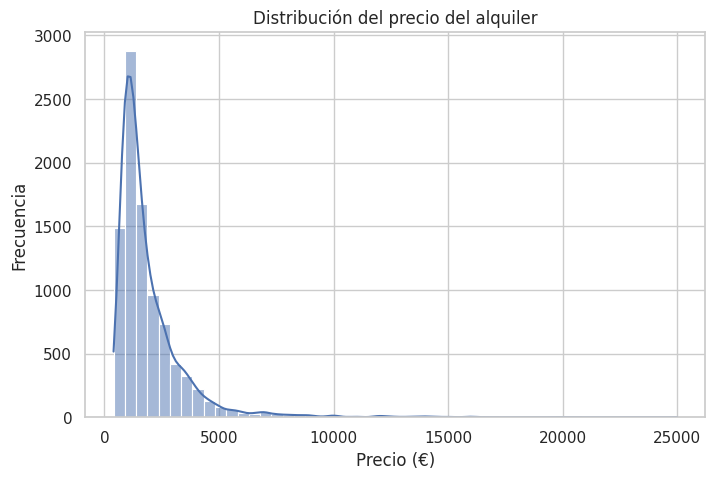

In [ ]:
# Histograma
plt.figure(figsize=(8,5))
sns.histplot(df_clean["price"], bins=50, kde=True)
plt.title("Distribución del precio del alquiler")
plt.xlabel("Precio (€)")
plt.ylabel("Frecuencia")
plt.show()

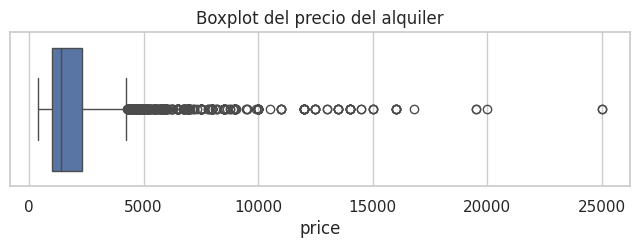

In [ ]:
# Diagrama de caja
plt.figure(figsize=(8,2))
sns.boxplot(x=df_clean["price"])
plt.title("Boxplot del precio del alquiler")
plt.show()

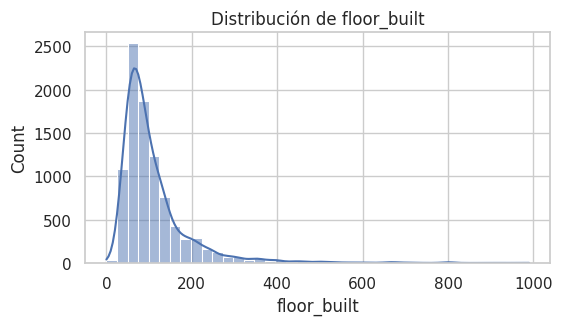

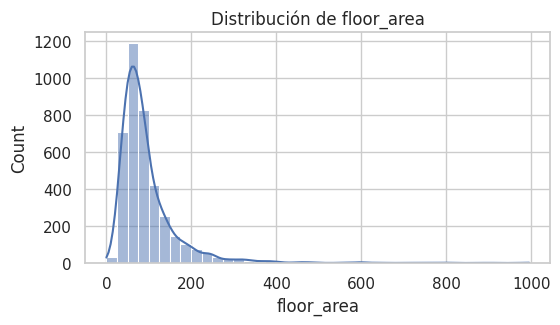

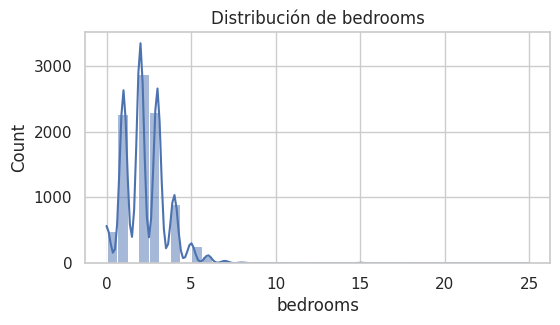

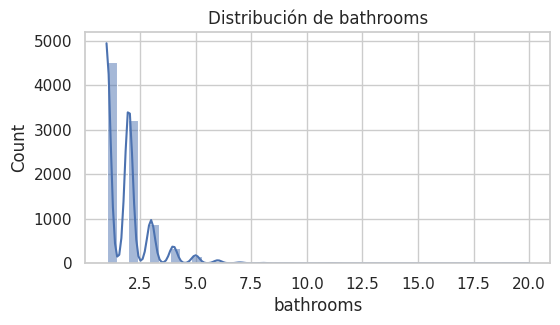

In [ ]:
# Otras variables
num_vars = ["floor_built", "floor_area", "bedrooms", "bathrooms"]

for col in num_vars:
    plt.figure(figsize=(6,3))
    sns.histplot(df_clean[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

# EDA BIVARIANTE

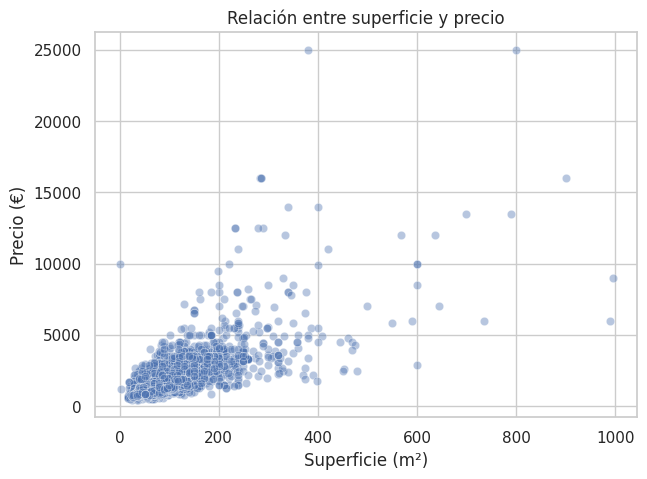

In [ ]:
# superficie/precio
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_clean,
    x="floor_area",
    y="price",
    alpha=0.4
)
plt.title("Relación entre superficie y precio")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (€)")
plt.show()

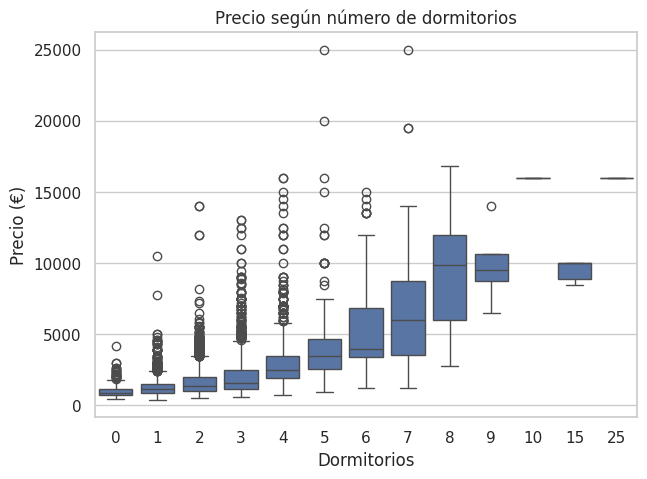

In [ ]:
# Precio según número de dormitorios
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df_clean,
    x="bedrooms",
    y="price"
)
plt.title("Precio según número de dormitorios")
plt.xlabel("Dormitorios")
plt.ylabel("Precio (€)")
plt.show()

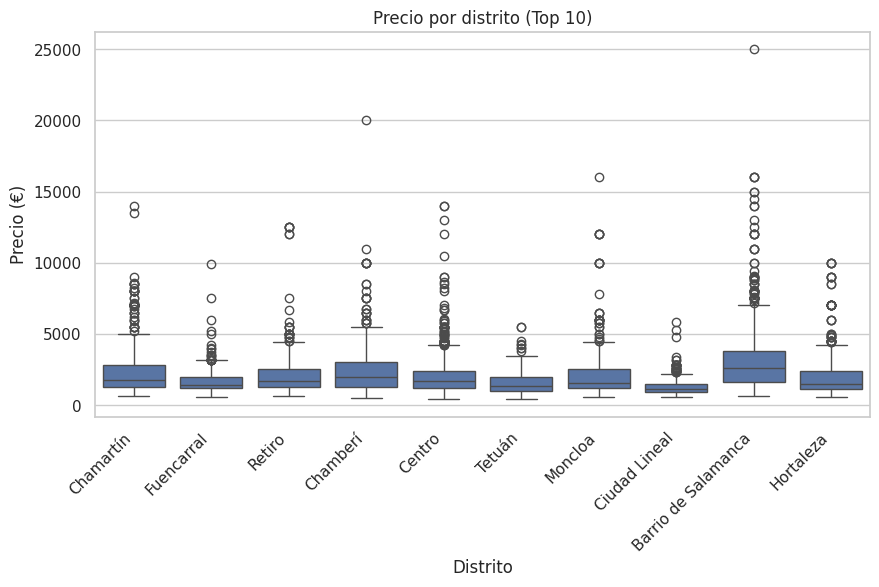

In [ ]:
# Precio según distrito
top_districts = df_clean["district"].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_clean[df_clean["district"].isin(top_districts)],
    x="district",
    y="price"
)
plt.xticks(rotation=45, ha="right")
plt.title("Precio por distrito (Top 10)")
plt.xlabel("Distrito")
plt.ylabel("Precio (€)")
plt.show()

# EDA MULTIVARIANTE Y CORRELACIONES

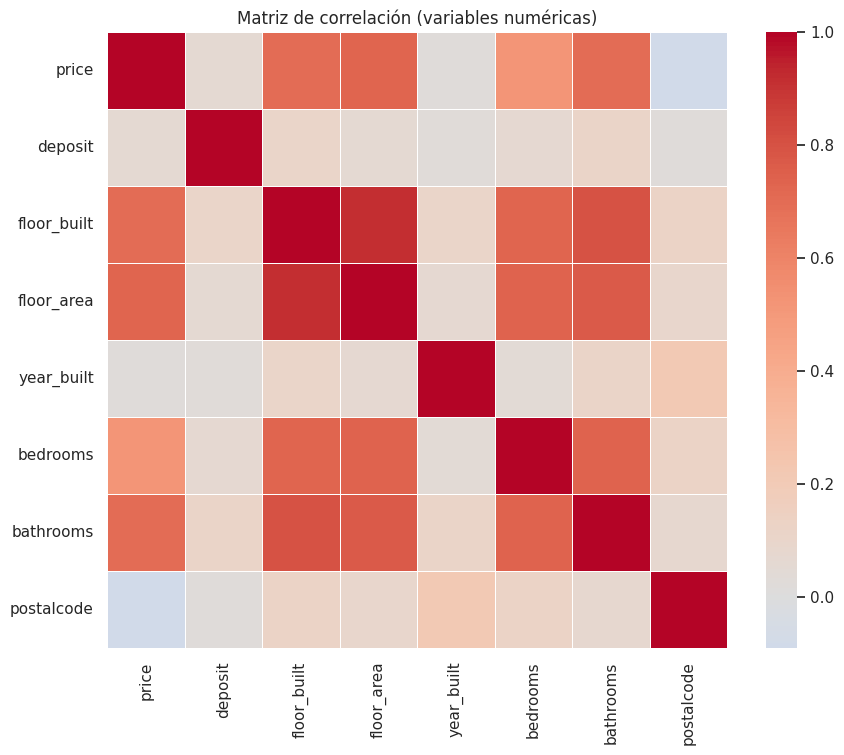

In [ ]:
# Matriz de correlación
plt.figure(figsize=(10,8))
corr = df_clean.select_dtypes(include=[np.number]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matriz de correlación (variables numéricas)")
plt.show()

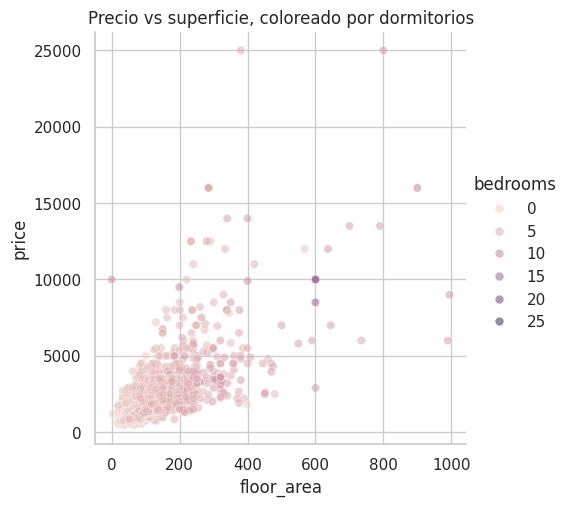

In [ ]:
# Vista multivariante
sns.relplot(
    data=df_clean,
    x="floor_area",
    y="price",
    hue="bedrooms",
    alpha=0.5
)
plt.title("Precio vs superficie, coloreado por dormitorios")
plt.show()

# Preparación de datos para ML

In [ ]:
# REGRESIÓN
target_reg = "price"

df_reg = df_clean.dropna(subset=[target_reg]).copy()

X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

print("Regresión -> X:", X_reg.shape, "| y:", y_reg.shape)

# CLASIFICACIÓN
target_clf = "balcony"

df_clf = df_clean.dropna(subset=[target_clf]).copy()

X_clf = df_clf.drop(columns=[target_clf])
y_clf = df_clf[target_clf].astype(int)

print("Clasificación -> X:", X_clf.shape, "| y:", y_clf.shape)

Regresión -> X: (9229, 26) | y: (9229,)
Clasificación -> X: (9229, 26) | y: (9229,)


# Pipeline de preprocesado

In [ ]:
# Columnas numéricas y categóricas
numeric_features = X_reg.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_reg.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", numeric_features)
print("\nCategóricas:", categorical_features)

Numéricas: ['deposit', 'floor_built', 'floor_area', 'year_built', 'bedrooms', 'bathrooms', 'postalcode']

Categóricas: ['type', 'private_owner', 'floor', 'orientation', 'second_hand', 'lift', 'garage_included', 'furnished', 'equipped_kitchen', 'fitted_wardrobes', 'air_conditioning', 'terrace', 'balcony', 'storeroom', 'swimming_pool', 'garden_area', 'location', 'district', 'subdistrict']


In [ ]:
# Definimos transformadores
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocesador creado correctamente")

Preprocesador creado correctamente


# Modelos de regresión

In [ ]:
# train / test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (7383, 26) Test: (1846, 26)


In [ ]:
# Definimos los modelos de regresión que vamos a comparar
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

regression_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [ ]:
# Entrenamos y evaluamos los modelos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results_reg = []

for name, model in regression_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results_reg.append((name, rmse, mae, r2))

results_reg_df = pd.DataFrame(
    results_reg,
    columns=["Modelo", "RMSE", "MAE", "R2"]
).sort_values("RMSE")

results_reg_df

             Modelo        RMSE         MAE        R2
2      RandomForest  575.428283  318.376816  0.851305
3  GradientBoosting  700.456357  429.385858  0.779669
1             Ridge  780.202203  471.038048  0.726644
0  LinearRegression  912.385421  535.377228  0.626173

# Regresión con transformación logarítmica

In [ ]:
# Variable logarítmica
df_reg_log = df_clean.copy()

df_reg_log["price_log"] = np.log1p(df_reg_log["price"])

X_log = df_reg_log.drop(columns=["price", "price_log"])
y_log = df_reg_log["price_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

In [ ]:
# Entrenamos el modelo (price)
pipe_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

pipe_log.fit(X_train, y_train)
y_pred_log = pipe_log.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

rmse_log, r2_log

(np.float64(0.24395364927688618), 0.8204980369610888)

# Red neuronal (Keras) para regresión

In [ ]:
# Transformamos los datos con el mismo preprocesador
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp = preprocessor.transform(X_test)

# Convertimos a array si es necesario
if hasattr(X_train_pp, "toarray"):
    X_train_pp = X_train_pp.toarray()
    X_test_pp = X_test_pp.toarray()

X_train_pp.shape, X_test_pp.shape

((7383, 5168), (1846, 5168))

In [ ]:
# Definimos la red neuronal
tf.random.set_seed(42)

model_reg = keras.Sequential([
    keras.layers.Input(shape=(X_train_pp.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])

model_reg.compile(
    optimizer="adam",
    loss="mse"
)

model_reg.summary()

In [ ]:
#Entrenamos la red
history = model_reg.fit(
    X_train_pp,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=0
)

In [ ]:
#Evaluamos la red
y_pred_nn = model_reg.predict(X_test_pp).ravel()

rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

rmse_nn, r2_nn

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


(np.float64(0.368257225684356), 0.5909681576591712)

# Curva de entrenamiento (Keras)

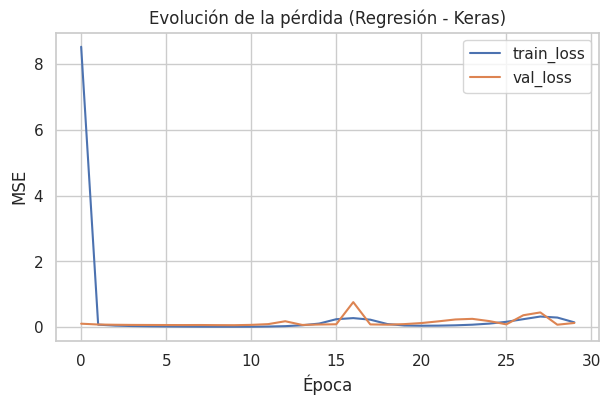

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Evolución de la pérdida (Regresión - Keras)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Clasificación binaria (balcony)

Comprobamos balanceo de clases

In [ ]:
y_clf.value_counts(normalize=True)

balcony
0    0.821216
1    0.178784
Name: proportion, dtype: float64

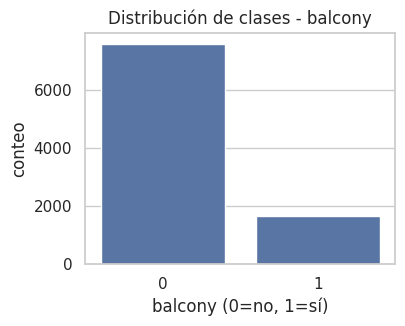

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(x=y_clf)
plt.title("Distribución de clases - balcony")
plt.xlabel("balcony (0=no, 1=sí)")
plt.ylabel("conteo")
plt.show()

In [ ]:
#Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (7383, 26) Test: (1846, 26)


In [ ]:
# Definimos columnas numéricas y categóricas
numeric_features_clf = X_clf.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_clf = X_clf.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas (clf):", numeric_features_clf)
print("Categóricas (clf):", categorical_features_clf)

Numéricas (clf): ['price', 'deposit', 'floor_built', 'floor_area', 'year_built', 'bedrooms', 'bathrooms', 'postalcode']
Categóricas (clf): ['type', 'private_owner', 'floor', 'orientation', 'second_hand', 'lift', 'garage_included', 'furnished', 'equipped_kitchen', 'fitted_wardrobes', 'air_conditioning', 'terrace', 'storeroom', 'swimming_pool', 'garden_area', 'location', 'district', 'subdistrict']


In [ ]:
preprocessor_clf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_clf),
        ("cat", categorical_transformer, categorical_features_clf)
    ]
)

print("Preprocesador de clasificación creado")

Preprocesador de clasificación creado


In [ ]:
#Entrenamos modelos clásicos de clasificación
clf_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42)
}

results_clf = []

for name, model in clf_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_clf),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    else:
        auc = np.nan

    results_clf.append((name, acc, f1, auc))

results_clf_df = pd.DataFrame(
    results_clf,
    columns=["Modelo", "Accuracy", "F1", "ROC_AUC"]
).sort_values("F1", ascending=False)

results_clf_df

                       Modelo  Accuracy        F1   ROC_AUC
0          LogisticRegression  0.830986  0.231527  0.715132
1      RandomForestClassifier  0.837486  0.230769  0.741684
2  GradientBoostingClassifier  0.826111  0.125341  0.704724

# Matriz de confusión

In [ ]:
# Modelo elegido para inspeccionar la matriz de confusión; no lidera todas las métricas.
best_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_clf),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

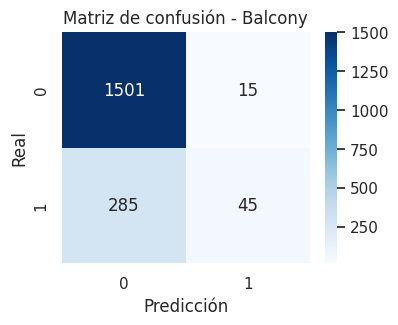

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1516
           1       0.75      0.14      0.23       330

    accuracy                           0.84      1846
   macro avg       0.80      0.56      0.57      1846
weighted avg       0.82      0.84      0.79      1846



In [ ]:
#Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Balcony")
plt.show()

print(classification_report(y_test, y_pred))

# Red neuronal (Keras) para clasificacion

In [ ]:
# Preprocesamos los datos para Keras
# Transformamos los datos
X_train_pp = preprocessor_clf.fit_transform(X_train)
X_test_pp = preprocessor_clf.transform(X_test)

# Convertimos a array si es necesario
if hasattr(X_train_pp, "toarray"):
    X_train_pp = X_train_pp.toarray()
    X_test_pp = X_test_pp.toarray()

X_train_pp.shape, X_test_pp.shape

((7383, 5119), (1846, 5119))

In [ ]:
# Definimos la red neuronal
tf.random.set_seed(42)

model_clf = keras.Sequential([
    keras.layers.Input(shape=(X_train_pp.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model_clf.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_clf.summary()

In [ ]:
# Entrenamos la red
history_clf = model_clf.fit(
    X_train_pp,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=0
)

In [ ]:
# Evaluamos la red neuronal
y_proba_nn = model_clf.predict(X_test_pp).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_proba_nn)

acc_nn, f1_nn, auc_nn

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


(0.7432286023835319, 0.3629032258064516, np.float64(0.6932617734068921))

# Tablas finales de resultados

In [ ]:
# Tabla final regresión
reg_table = results_reg_df.copy()
reg_table

             Modelo        RMSE         MAE        R2
2      RandomForest  575.428283  318.376816  0.851305
3  GradientBoosting  700.456357  429.385858  0.779669
1             Ridge  780.202203  471.038048  0.726644
0  LinearRegression  912.385421  535.377228  0.626173

In [ ]:
# Tabla final clasificación
clf_table = results_clf_df.copy()
clf_table

                       Modelo  Accuracy        F1   ROC_AUC
0          LogisticRegression  0.830986  0.231527  0.715132
1      RandomForestClassifier  0.837486  0.230769  0.741685
2  GradientBoostingClassifier  0.826111  0.125341  0.704724

## Conclusiones

En las salidas de la entrega original, Random Forest obtiene el menor RMSE de los cuatro regresores tabulares comparados: R² = 0,851 y MAE ≈ 318 € sobre el conjunto de prueba. Es una evaluación histórica con partición aleatoria; no demuestra generalización a otras fechas o mercados.

La regresión con Ridge y la red neuronal posteriores usan log1p(price). Sus errores están en escala logarítmica y no deben compararse directamente con los errores en euros.

La clasificación de presencia de balcón presenta desbalance. Entre los modelos clásicos, Logistic Regression logra un F1 ligeramente superior y Random Forest un ROC AUC mayor. La red neuronal mejora F1, pero reduce accuracy y ROC AUC. No hay un ganador en todas las métricas.

Antes de un uso real convendría revisar duplicados, separar validación y prueba, incorporar un baseline simple y evaluar por fecha o inmueble.